**FEBS PRACTICAL COURSE 2026: Generative AI for protein engineering**

**Notebook developed by Núria Mimbrero.**

# **REXzyme MODEL**

REXzyme is an encoder-decoder transformer. This protein Language Model generates enzymes for user-defined chemical reactions by prompting in SMILES notation.

The encoder reads the target reaction and the decoder predicts (auto-regressively) the associated enzyme. The model learns the mechanism behind chemical reactions and the role of enzymes in catalysin them, and ideally, to generalize to unseen reactions.

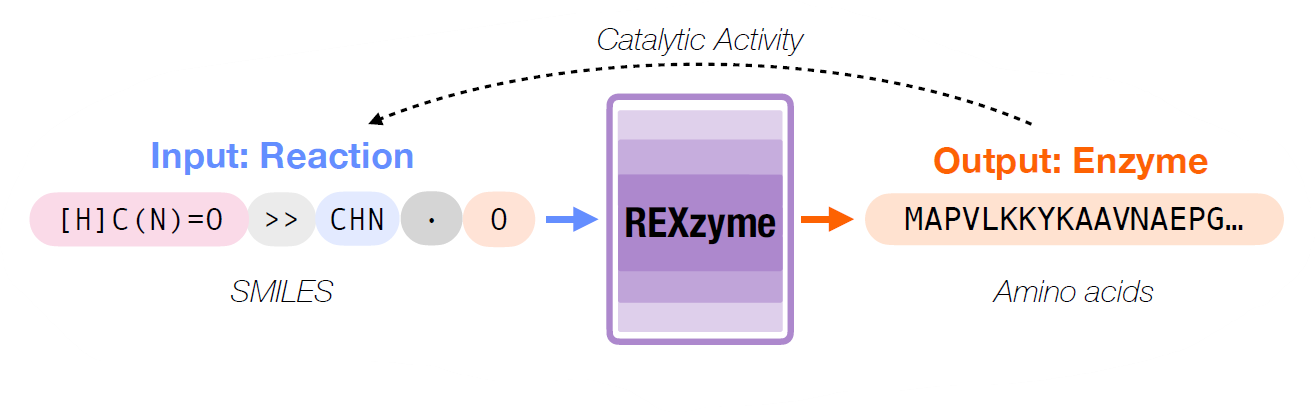

## Example: **Design of carbonic anhydrase using REXzyme**

**1. Install required packages**

In [ ]:
! pip install transformers torch torchvision torchaudio match

**2. Import required modules**

In [ ]:
from transformers import AutoTokenizer
from transformers import AutoModelForSeq2SeqLM
import torch
import math

**3. Load tokenizers from HuggingFace**

In [ ]:
# Molecule SMILES tokenizer
tokenizer_mol = AutoTokenizer.from_pretrained(
    "AI4PD/REXzyme",
    subfolder="tokenizer_aa--ABPE_SMILES/tokenizer_ABPE_rexzyme_offset"
)

# Amino acid tokenizer
tokenizer_aa = AutoTokenizer.from_pretrained(
    "AI4PD/REXzyme",
    subfolder="tokenizer_aa"
)

**4. Load REXzyme model**

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoModelForSeq2SeqLM.from_pretrained(
    "AI4PD/REXzyme",       # repo name
    subfolder="checkpoint-90000"  # the checkpoint folder inside the repo
)
model.to(device)
model.eval()

**5. Generate sequences for a target reaction SMILE**

In [ ]:
reaction_smiles = "O=C([O-])O.[H+]>>O.O=C=O"  # your input (carbonic anhydrase in this case)
inputs = tokenizer_mol(reaction_smiles, return_tensors="pt").to(device)

# sample multiple enzyme sequences
outputs = model.generate(
    **inputs,
    max_length=1024,         # maximum lenght of the generated sequences
    top_k=100,               # sampling parameters
    top_p=1.0,               # sampling parameters
    repetition_penalty=1.0,  # sampling parameters
    do_sample=True,
    num_return_sequences=5   # number of designs
)

# decode with the protein tokenizer
enzymes = [tokenizer_aa.decode(output, skip_special_tokens=True) for output in outputs]
for seq in enzymes:
    print(seq)

In [ ]:
## COMPUTING PERPLEXITY AS WELL
# Example input SMILES
reaction_smiles = "O=C([O-])O.[H+]>>O.O=C=O"
inputs = tokenizer_mol(reaction_smiles, return_tensors="pt").to(device)

# Generate sequences
outputs = model.generate(
    **inputs,
    max_length=1024,
    top_k=100,
    top_p=1.0,
    repetition_penalty=1.0,
    do_sample=True,
    num_return_sequences=5
)

# Decode outputs
generated_sequences = [tokenizer_aa.decode(o, skip_special_tokens=True) for o in outputs]
print("\nGenerated sequences:")
for seq in generated_sequences:
    print(seq)


# --- Perplexity calculation ---
def calculate_perplexity(model, src_ids, tgt_ids, tgt_tokenizer):
    """Conditional perplexity P(tgt | src)"""
    labels = tgt_ids.clone()
    labels[labels == tgt_tokenizer.pad_token_id] = -100  # ignore padding
    with torch.no_grad():
        outputs = model(input_ids=src_ids, labels=labels)
        loss = outputs.loss
    return math.exp(loss.item())

print("\nPerplexities:")
for i, seq in enumerate(outputs):
    tgt = seq.unsqueeze(0)  # batch dim
    ppl = calculate_perplexity(model, src_ids=inputs["input_ids"], tgt_ids=tgt, tgt_tokenizer=tokenizer_aa)
    print(f"Sequence {i}: PPL = {ppl:.2f}")